In [2]:
import numpy as np    # for mathematical operations
import pandas as pd     # analyse data or for dataframes
from sklearn.datasets import make_classification # for own datasets


In [4]:
X, y = make_classification(n_samples = 1000, n_features = 6, n_informative = 2, n_classes = 2, random_state = 134)
# classification data with 6 features : 2 informative vars and 4 non-informative vars 

In [8]:
df = pd.DataFrame(X, columns = [f'x{i}' for i in range(1, 7)])
df['target'] = y 
# converting into pandas dataframe with col names x1, x2, x3, till x6
# assigning target var as y

In [9]:
df 

,x1,x2,x3,x4,x5,x6,target
0,-0.175607,2.096776,0.193515,-0.197979,0.614337,0.152221,0
1,-0.237559,-0.900253,0.851576,0.122654,-0.659372,0.597719,1
2,-0.619941,0.631125,3.617209,1.243602,-0.232297,2.486463,1
3,1.267036,-0.086827,-0.899692,1.757201,2.059507,-0.768438,0
4,0.286389,-1.264438,-2.358642,-1.029750,-0.792644,-1.605442,0
...,...,...,...,...,...,...,...
995,1.761970,-0.909970,-0.783485,2.753219,-0.956613,-0.757950,0
996,-0.867464,-1.030907,-1.262156,-2.446485,-0.547518,-0.721530,0
997,-2.901635,0.011812,3.165859,-3.292270,0.788811,2.494164,1
998,0.769074,0.267471,-1.052058,0.731624,0.563602,-0.802538,1


In [16]:
from sklearn.model_selection import train_test_split # importing scikit learn model for training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    df.drop('target', axis = 1), df['target'], test_size = 0.2, random_state = 134, stratify = df['target']
) # dropping rows : stratified - divides a dataset into training and testing like it maintains same proportion as it will be in original dataset

#nested train validation
X_train1, X_val, y_train1, y_val = train_test_split(X_train, y_train, test_size = 0.25, random_state = 134, stratify = y_train)




In [17]:
X_train.shape #shape of training set

(800, 6)

In [18]:
X_test.shape #shape of testing set

(200, 6)

In [19]:
X_train1.shape #training set

(600, 6)

In [20]:
X_val.shape #validation set

(200, 6)

In [21]:
import matplotlib.pyplot as plt #for visualisation
import seaborn as sns #for scatter plot

In [22]:
def create_scatter_plot(data, labels):

    if isinstance(data, pd.DataFrame):    #pandas dataframes
        x1 = data.iloc[:, 0] #particular location
        x2 = data.iloc[:, 1]

    elif isinstance(data, np.ndarray):    #for numpy arrays
        x1 = data[:, 0]
        x2 = data[:, 1]

    else:
        raise ValueError("Input data must be numpy array or pandas DataFrame")

    palette = "colorblind"   #color for scatter plot

    #creating scatter plot
    plt.figure(figsize = (10, 6))
    sns.scatterplot(x = x1, y = x2, hue = labels, palette = palette)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Scatter plot of Feature 1 vs Feature 2')
    plt.show()

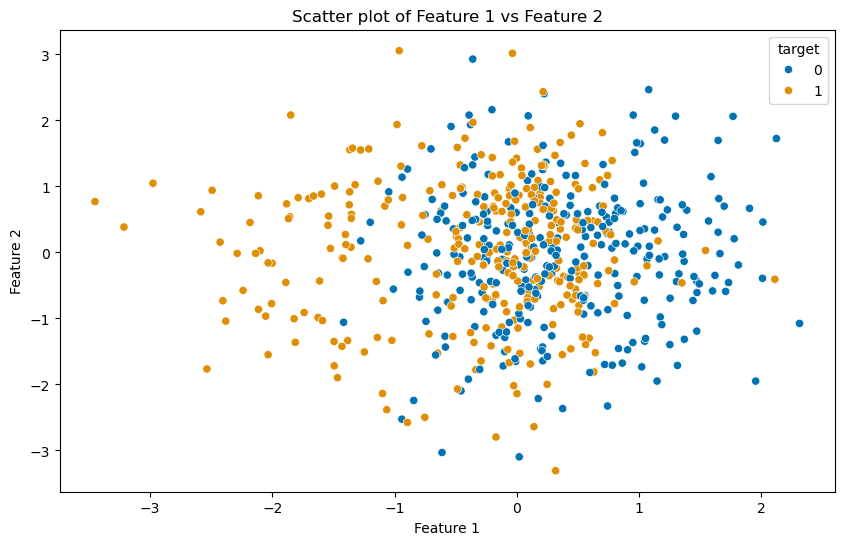

In [23]:
create_scatter_plot(data = X_train1, labels = y_train) # training set of x and y

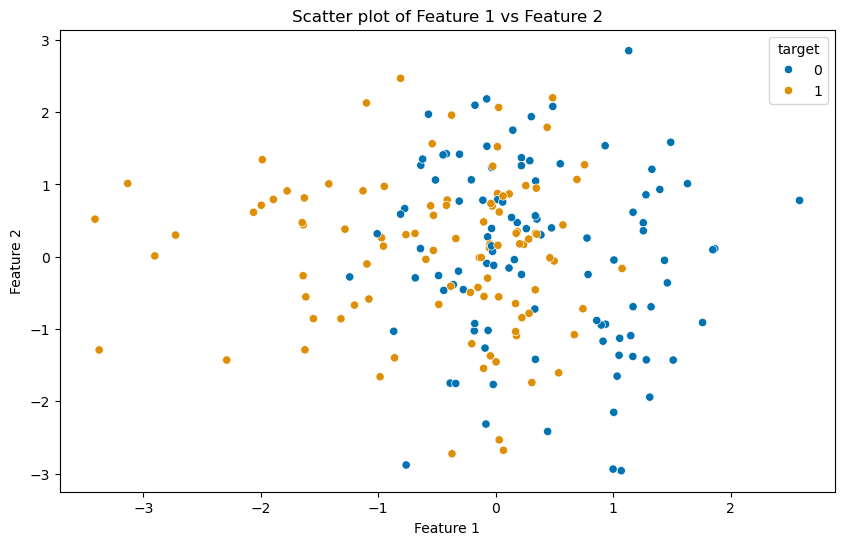

In [24]:
create_scatter_plot(data = X_val, labels = y_val)  #validation set

In [25]:
from sklearn.linear_model import LogisticRegression #importing logistic regression from scikit learn

#creating logistic regression model
lr_model = LogisticRegression(random_state = 123)

lr_model.fit(X_train1, y_train1) #fitting the model to training data



LogisticRegression(random_state=123)

In [27]:
y_pred = lr_model.predict(X_val) #prediction on validation set

y_pred

array([1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 0])

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_val, y_pred) #accuracy tp+tn/tp+tn+fp+fn

precision = precision_score(y_val, y_pred) #precision tp/tp+fp

recall = recall_score(y_val, y_pred) #recall tp/tp+fn

f1 = f1_score(y_val, y_pred) #f1 score / f measure 

#printing evaluation results with only 2 decimal points
print("Validation Accuracy: {:.2f}".format(accuracy))

print("Validation Precision: {:.2f}".format(precision))

print("Validation Recall: {:.2f}".format(recall))

print("Validation F1-score: {:.2f}".format(f1))

print(classification_report(y_val, y_pred)) #classification report

cm = confusion_matrix(y_val, y_pred) #confusion matrix
print("Confusion Matrix:\n", cm)

Validation Accuracy: 0.88
Validation Precision: 0.84
Validation Recall: 0.94
Validation F1-score: 0.89
              precision    recall  f1-score   support

           0       0.93      0.82      0.87       100
           1       0.84      0.94      0.89       100

    accuracy                           0.88       200
   macro avg       0.89      0.88      0.88       200
weighted avg       0.89      0.88      0.88       200

Confusion Matrix:
 [[82 18]
 [ 6 94]]


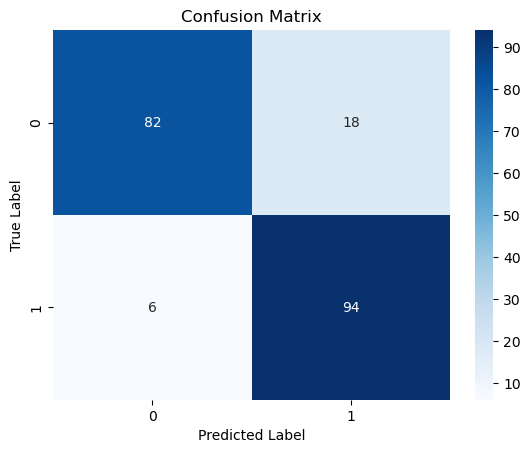

In [30]:
# plotting cm with heatmap

sns.heatmap(cm, annot = True, cmap = "Blues", fmt = "d")

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.show()

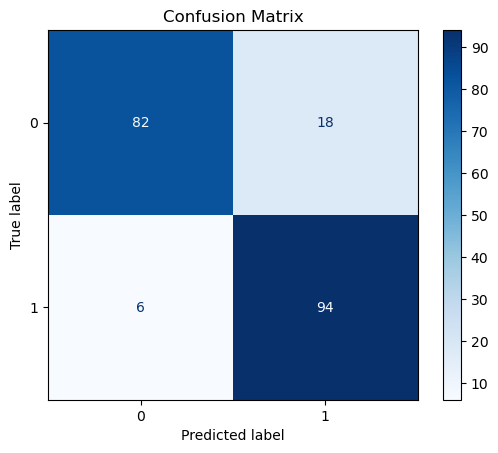

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(lr_model, X_val, y_val, cmap = "Blues") #create plots or objects directly from our trained model 

plt.title("Confusion Matrix")

plt.show()

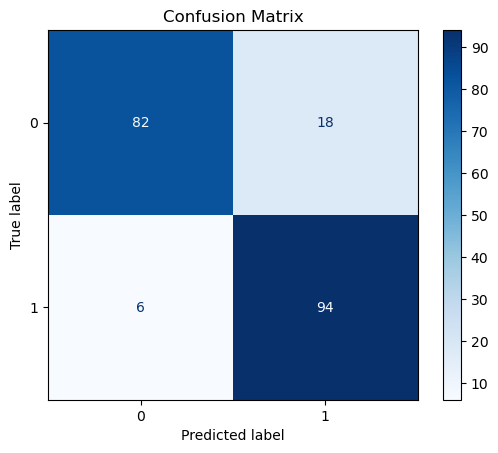

In [32]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, cmap="Blues")  #we already have model predictions so we use from predictions

plt.title("Confusion Matrix")

plt.show()

In [33]:
C_values = np.logspace(-4, 4, num = 9, base = 10) #generates c values between 0.0001 to 10000 ; 10 folds or CV

C_values

array([1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03,
       1.e+04])

In [34]:
#empty lists to store performance metrics
train_accuracies = []

val_accuracies = []

for c in C_values: #to go through each value in C
    
    lr_model = LogisticRegression(C=c, random_state=134) #logistic regression model with current value of C   
    
    lr_model.fit(X_train, y_train) #fitting the model on training set
    
    y_train_pred = lr_model.predict(X_train) #predictions on training set
    
    y_val_pred = lr_model.predict(X_val) #predictions on validation set
    
    train_acc = accuracy_score(y_train, y_train_pred) #accuracy for training set
    
    val_acc = accuracy_score(y_val, y_val_pred) #accuracy for validation set
    
    #appending/adding values to particular lists
    train_accuracies.append(train_acc)
    
    val_accuracies.append(val_acc)

#converting results to numpy arrays
train_accuracies = np.array(train_accuracies)

val_accuracies = np.array(val_accuracies)

#results rounding to 3 dec points
train_accuracies = np.round(train_accuracies, 3)

val_accuracies = np.round(val_accuracies, 3)

#printing the results
for i in range(len(C_values)):
    print(f"C: {C_values[i]}, Train Accuracy: {train_accuracies[i]}, Val Accuracy: {val_accuracies[i]}")

C: 0.0001, Train Accuracy: 0.864, Val Accuracy: 0.82
C: 0.001, Train Accuracy: 0.87, Val Accuracy: 0.825
C: 0.01, Train Accuracy: 0.894, Val Accuracy: 0.87
C: 0.1, Train Accuracy: 0.899, Val Accuracy: 0.865
C: 1.0, Train Accuracy: 0.902, Val Accuracy: 0.875
C: 10.0, Train Accuracy: 0.904, Val Accuracy: 0.88
C: 100.0, Train Accuracy: 0.904, Val Accuracy: 0.88
C: 1000.0, Train Accuracy: 0.904, Val Accuracy: 0.88
C: 10000.0, Train Accuracy: 0.904, Val Accuracy: 0.88


In [37]:
train_accuracies #viewing accuracies 

array([0.864, 0.87 , 0.894, 0.899, 0.902, 0.904, 0.904, 0.904, 0.904])

In [38]:
val_accuracies

array([0.82 , 0.825, 0.87 , 0.865, 0.875, 0.88 , 0.88 , 0.88 , 0.88 ])

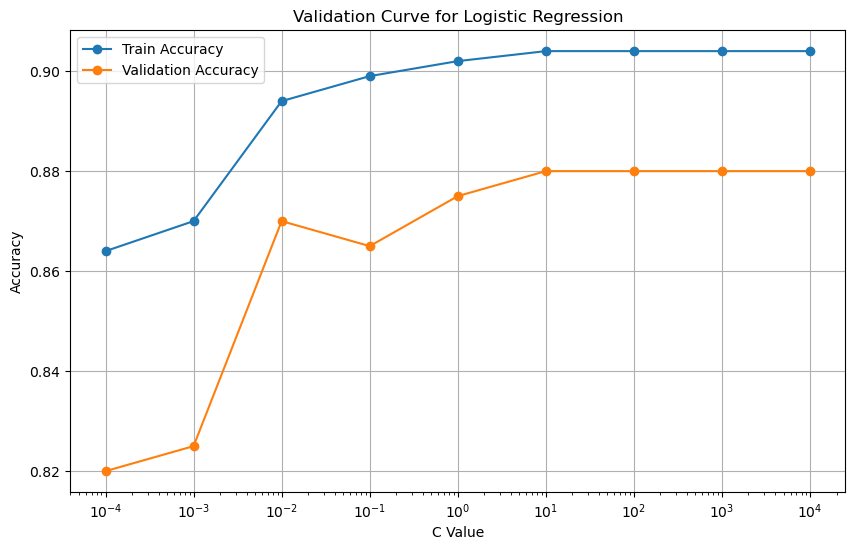

In [39]:
#creating validation curve 
plt.figure(figsize = (10, 6))

plt.plot(C_values, train_accuracies, 'o-', label = 'Train Accuracy')

plt.plot(C_values, val_accuracies, 'o-', label = 'Validation Accuracy')

plt.xlabel('C Value')

plt.ylabel('Accuracy')

plt.xscale('log')

plt.title('Validation Curve for Logistic Regression')

plt.legend()

plt.grid(True)

plt.show()


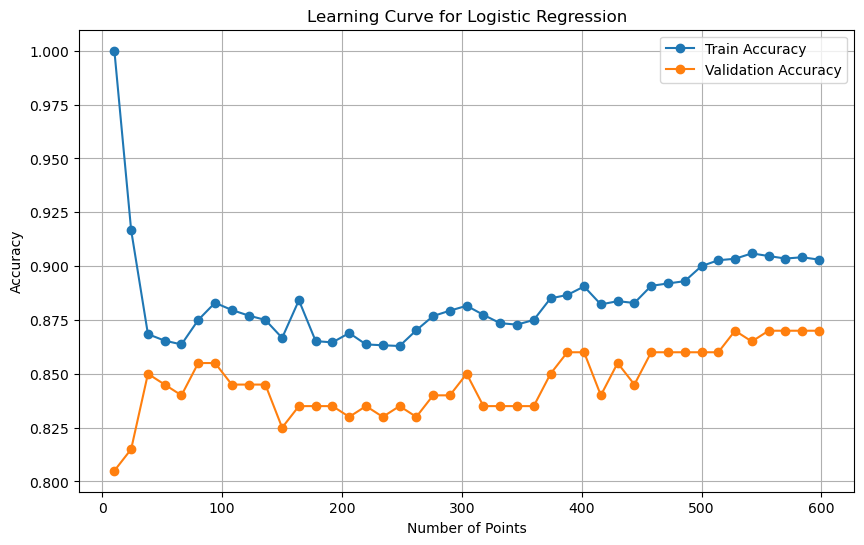

In [42]:
train_accuracies = []

val_accuracies = []

#number of points
num_points = list(range(10, 610, 14))

for num in num_points: #loop over points
    # Select a subset of training data
    X_train_subset = X_train[:num]
    
    y_train_subset = y_train[:num]
    
   #training lr model
    model = LogisticRegression()
    
    model.fit(X_train_subset, y_train_subset)
    
    #predictions on the training and validation sets
    y_train_pred = model.predict(X_train_subset)
    
    y_val_pred = model.predict(X_val)
    
    #accuracy for training and validation sets
    train_acc = accuracy_score(y_train_subset, y_train_pred)
    
    val_acc = accuracy_score(y_val, y_val_pred)
    
    # add accuracies to theie lists
    train_accuracies.append(train_acc)
    
    val_accuracies.append(val_acc)

#lists to numpy arrays
train_accuracies = np.array(train_accuracies)

val_accuracies = np.array(val_accuracies)

#line plot with dots
plt.figure(figsize=(10, 6))

plt.plot(num_points, train_accuracies, 'o-', label='Train Accuracy')

plt.plot(num_points, val_accuracies, 'o-', label='Validation Accuracy')

plt.xlabel('Number of Points')

plt.ylabel('Accuracy')

plt.title('Learning Curve for Logistic Regression')

plt.legend()

plt.grid(True)

plt.show()


Accuracy: 0.885
Precision: 0.905
Recall: 0.860
F1-score: 0.882
              precision    recall  f1-score   support

           0       0.87      0.91      0.89       100
           1       0.91      0.86      0.88       100

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.88       200
weighted avg       0.89      0.89      0.88       200



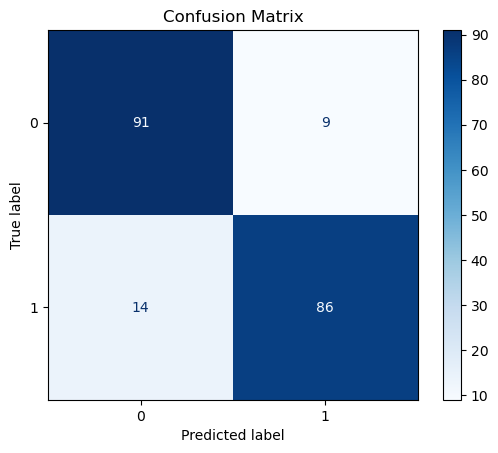

In [45]:
#FINAL MODEL 
#creating and training a logistic regression model with C=1
final_model = LogisticRegression(C = 1, random_state = 134)

final_model.fit(X_train, y_train)

#predictions on the testing set
y_pred = final_model.predict(X_test)

#performance metrics
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)


# printing performance metrics
print(f"Accuracy: {accuracy:.3f}")

print(f"Precision: {precision:.3f}")

print(f"Recall: {recall:.3f}")

print(f"F1-score: {f1:.3f}")


#classification report
print(classification_report(y_test, y_pred))

#confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap = "Blues")

plt.title("Confusion Matrix")

plt.show()